# Regressão Logística

**Francisco A. Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

### Introdução

Em **regressão linear**, prevemos um número contínuo (ex.: preço de uma casa, temperatura). Mas muitas perguntas do mundo real têm resposta **sim/não**:

- Este e-mail é spam ou não?
- Este paciente tem ou não uma doença?
- Este cliente vai cancelar a assinatura ou não?

Chamamos isso de **classificação binária**: a variável alvo $y$ assume apenas dois valores, tipicamente codificados como $0$ (classe negativa) e $1$ (classe positiva).

Poderíamos tentar usar regressão linear diretamente ($y = \beta_0 + \beta_1 x$), mas isso tem dois problemas sérios:

1. A reta pode prever valores menores que 0 ou maiores que 1, o que não faz sentido para uma probabilidade.
2. A relação entre as variáveis explicativas e a probabilidade de "sucesso" raramente é linear, ela tende a ter formato de "S" (saturando perto de 0 e de 1).

A **regressão logística** resolve isso modelando não a classe diretamente, mas a **probabilidade** de pertencer à classe positiva, usando uma função que é sempre limitada entre 0 e 1: a **função sigmoide**.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Onde $z$ é uma combinação linear das variáveis explicativas (chamada de **logit** ou **score**):

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

O modelo completo de regressão logística é:

$$P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p)}}$$

Propriedades importantes da sigmoide:

- Quando $z \to +\infty$, $\sigma(z) \to 1$.
- Quando $z \to -\infty$, $\sigma(z) \to 0$.
- Quando $z = 0$, $\sigma(z) = 0.5$.
- É estritamente crescente (se o "score" aumenta, a probabilidade prevista aumenta).

Vamos visualizar essa curva.

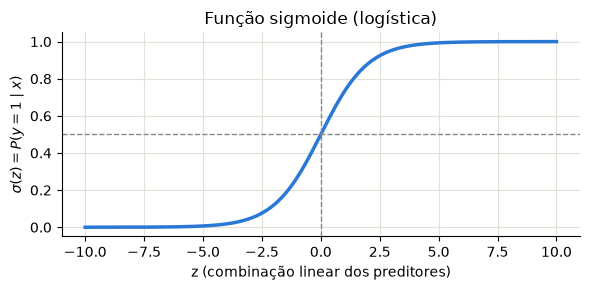

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paleta consistente usada em todo o notebook
BLUE   = "#2a78d6"   # classe negativa / modelo
ORANGE = "#eb6834"   # classe positiva
GRAY   = "#898781"   # referência / baseline
INK    = "#0b0b0b"
GRID   = "#e1e0d9"

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400)
p = sigmoid(z)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z, p, color=BLUE, linewidth=2.5)
ax.axhline(0.5, color=GRAY, linestyle="--", linewidth=1)
ax.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax.set_xlabel("z (combinação linear dos preditores)")
ax.set_ylabel(r"$\sigma(z) = P(y=1 \mid x)$")
ax.set_title("Função sigmoide (logística)")
ax.grid(color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


Uma forma equivalente e muito útil de olhar para o modelo é através das **chances (odds)**. Se $p$ é a probabilidade de sucesso, as chances são:

$$\text{odds} = \frac{p}{1-p}$$

E o modelo de regressão logística pode ser reescrito como:

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p,$$

onde $p(x)=P(Y=1\mid X=x)$. Ou seja: **o logaritmo das chances (log-odds, ou "logit") é uma função linear dos preditores.** Essa é a razão do nome "regressão logística". O *logit* é modelado de forma linear, mesmo que a probabilidade não seja.

Essa formulação também dá uma interpretação direta aos coeficientes: $e^{\beta_1}$ é o **odds ratio (razão de chances)** associado a um aumento de uma unidade em $x_1$, mantendo as demais variáveis constantes.

- $e^{\beta_1} > 1$: aumentar $x_1$ aumenta as chances da classe positiva.
- $e^{\beta_1} < 1$: aumentar $x_1$ diminui as chances da classe positiva.
- $e^{\beta_1} = 1$: $x_1$ não tem efeito.

Vamos usar isso mais adiante para interpretar um modelo real.

**Função de custo: por que não usar o erro quadrático?**

Se usássemos o erro quadrático médio (MSE), como na regressão linear, a função de custo resultante em relação aos parâmetros seria **não convexa** para a regressão logística, de forma que teria múltiplos mínimos locais, dificultando a otimização.

Em vez disso, a regressão logística é ajustada por **máxima verossimilhança**, o que equivale a minimizar a **entropia cruzada (log-loss)**:

$$J(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \ln(\hat p_i) + (1-y_i)\ln(1-\hat p_i)\Big]$$

Se o exemplo é da classe positiva ($y_i=1$) e o modelo previu $\hat p_i$ próximo de 1, o custo daquele exemplo é próximo de 0. Se o modelo previu $\hat p_i$ próximo de 0 para esse mesmo exemplo, o custo tende a $+\infty$, que é ruim, pois o modelo estava "confiante e errado". Essa função é **convexa**, o que garante que métodos como gradiente descendente convirjam para o mínimo global.

Na prática, não implementaremos o gradiente descendente manualmente aqui. Usaremos a implementação otimizada do `scikit-learn` (`LogisticRegression`), que resolve esse problema de otimização internamente.

**Regularização**

Para evitar overfitting, o `scikit-learn` aplica, por padrão, **regularização L2 (Ridge)**, que é um termo de penalização que "encolhe" os coeficientes em direção a zero. A força dessa penalização é controlada pelo hiperparâmetro `C`: valores **menores de C significam mais regularização**. Também é possível usar regularização **L1 (Lasso)**, que pode zerar coeficientes (fazendo seleção de variáveis). Vamos explorar isso na seção de ajuste de hiperparâmetros.


### 2. Configurando o ambiente

Vamos importar todas as bibliotecas que usaremos no notebook. Usamos principalmente `numpy`, `pandas`, `matplotlib` e `scikit-learn`.


In [2]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Algumas versões recentes do scikit-learn emitem avisos de depreciação sobre o
# parâmetro `penalty` do LogisticRegression; eles não afetam os resultados deste
# notebook, então os silenciamos para manter as saídas limpas e didáticas.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Inconsistent values")

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_validate, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta consistente (definida novamente aqui para o caso deste bloco
# ser executado de forma independente do bloco da Seção 1)
BLUE, ORANGE, GRAY, INK, GRID = "#2a78d6", "#eb6834", "#898781", "#0b0b0b", "#e1e0d9"

plt.rcParams["axes.edgecolor"] = GRID
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = GRID
plt.rcParams["grid.linewidth"] = 0.8
plt.rcParams["axes.axisbelow"] = True

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


### 3. Dados artificiais

A grande vantagem de dados artificiais (sintéticos) é que **nós sabemos exatamente como eles foram gerados**. Isso nos permite visualizar com clareza o que o modelo está aprendendo, sem as complicações de um problema real.

Imagine um cenário simples: queremos prever se um(a) estudante **será aprovado(a)** em uma prova ($y=1$) ou não ($y=0$), com base no **número de horas estudadas** ($x$). Vamos simular esse cenário.

In [3]:
rng = np.random.default_rng(RANDOM_STATE)

n = 120
horas_estudo = rng.uniform(0, 10, n)

# Probabilidade "verdadeira" de aprovação cresce com as horas estudadas,
# seguindo uma sigmoide com algum ruído.
z_verdadeiro = -4 + 1.0 * horas_estudo
prob_verdadeira = sigmoid(z_verdadeiro)
aprovado = rng.binomial(1, prob_verdadeira)

df_1d = pd.DataFrame({"horas_estudo": horas_estudo, "aprovado": aprovado})
print(f"O dataframe contém {df_1d.shape[0]} linhas e {df_1d.shape[1]} colunas.")
df_1d.head()


O dataframe contém 120 linhas e 2 colunas.


,horas_estudo,aprovado
0,7.739560,1
1,4.388784,0
2,8.585979,1
3,6.973680,1
4,0.941773,0


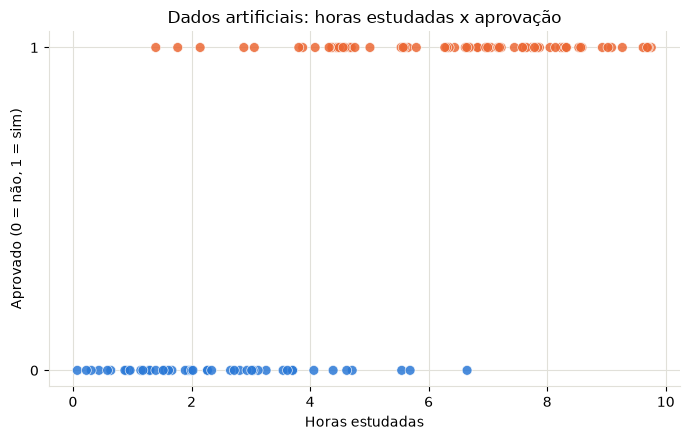

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(df_1d["horas_estudo"], df_1d["aprovado"],
           c=np.where(df_1d["aprovado"] == 1, ORANGE, BLUE),
           edgecolor="white", linewidth=0.5, s=50, alpha=0.85)

ax.set_xlabel("Horas estudadas")
ax.set_ylabel("Aprovado (0 = não, 1 = sim)")
ax.set_title("Dados artificiais: horas estudadas x aprovação")
ax.set_yticks([0, 1])
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



Note que os pontos só existem em $y=0$ ou $y=1$. Vamos agora ajustar um modelo de regressão logística e sobrepor a curva sigmoide aprendida.


In [5]:
X_1d = df_1d[["horas_estudo"]].values
y_1d = df_1d["aprovado"].values

modelo_1d = LogisticRegression()
modelo_1d.fit(X_1d, y_1d)

b0 = modelo_1d.intercept_[0]
b1 = modelo_1d.coef_[0][0]
print(f"Intercepto (beta_0): {b0:.3f}")
print(f"Coeficiente de horas_estudo (beta_1): {b1:.3f}")

# Ponto em que a probabilidade prevista é exatamente 0.5 (fronteira de decisão)
fronteira = -b0 / b1
print(f"Fronteira de decisão (p=0.5): {fronteira:.2f} horas")

Intercepto (beta_0): -3.924
Coeficiente de horas_estudo (beta_1): 1.028
Fronteira de decisão (p=0.5): 3.82 horas


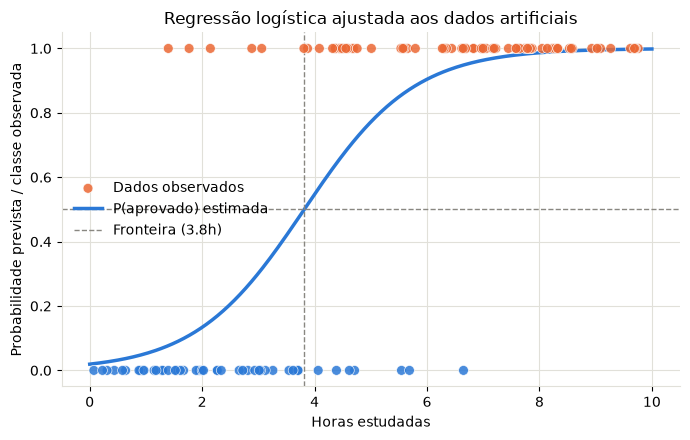

In [6]:
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)
p_plot = modelo_1d.predict_proba(x_plot)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df_1d["horas_estudo"], df_1d["aprovado"],
           c=np.where(df_1d["aprovado"] == 1, ORANGE, BLUE),
           edgecolor="white", linewidth=0.5, s=50, alpha=0.85, label="Dados observados", zorder=3)
ax.plot(x_plot, p_plot, color=BLUE, linewidth=2.5, label="P(aprovado) estimada", zorder=2)
ax.axhline(0.5, color=GRAY, linestyle="--", linewidth=1)
ax.axvline(fronteira, color=GRAY, linestyle="--", linewidth=1, label=f"Fronteira ({fronteira:.1f}h)")
ax.set_xlabel("Horas estudadas")
ax.set_ylabel("Probabilidade prevista / classe observada")
ax.set_title("Regressão logística ajustada aos dados artificiais")
ax.legend(frameon=False, loc="center left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

A curva em azul é exatamente a função sigmoide, mas agora ajustada aos dados: ela mostra, para cada quantidade de horas estudadas, a probabilidade estimada de aprovação. O ponto onde ela cruza $p=0.5$ é a **fronteira de decisão**: à direita dela, o modelo prevê "aprovado"; à esquerda, "reprovado".

Vamos agora considerar o caso com duas variáveis.

Com duas variáveis explicativas, a fronteira de decisão deixa de ser um ponto e passa a ser uma **reta** (em dimensões maiores, um hiperplano). Vamos gerar um conjunto de dados 2D sintético usando `make_classification`, que é a forma padrão do `scikit-learn` para gerar dados de classificação com controle sobre separabilidade, ruído, etc.

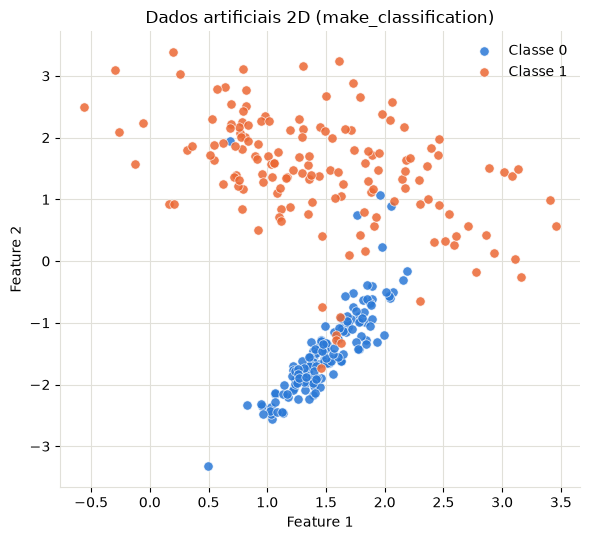

In [7]:
X_2d, y_2d = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    flip_y=0.03,       # um pouco de ruído/sobreposição entre as classes
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(6, 5.5))

ax.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], c=BLUE, edgecolor="white",
           linewidth=0.5, s=45, alpha=0.85, label="Classe 0")
ax.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], c=ORANGE, edgecolor="white",
           linewidth=0.5, s=45, alpha=0.85, label="Classe 1")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Dados artificiais 2D (make_classification)")
ax.legend(frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

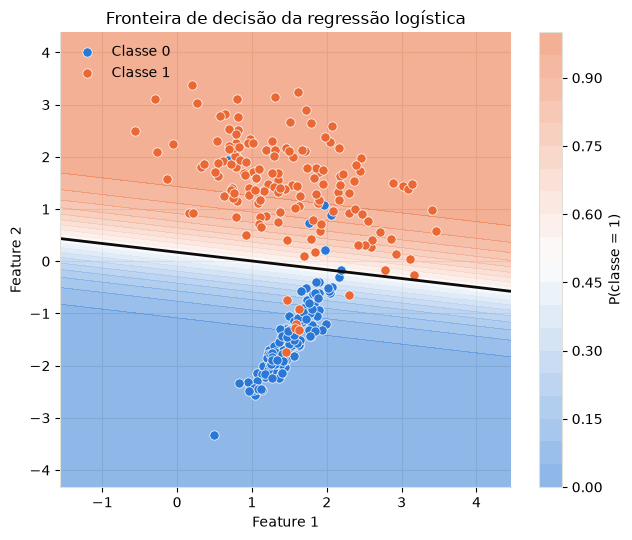

In [8]:
modelo_2d = LogisticRegression()
modelo_2d.fit(X_2d, y_2d)

# Malha de pontos para desenhar a fronteira de decisão
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = modelo_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

# Colormap sequencial (azul -> laranja) construído a partir da paleta do notebook
cmap_fundo = mcolors.LinearSegmentedColormap.from_list("fundo", [BLUE, "#fcfcfb", ORANGE])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
contorno = ax.contourf(xx, yy, probs, levels=20, cmap=cmap_fundo, alpha=0.55)
ax.contour(xx, yy, probs, levels=[0.5], colors=INK, linewidths=2)  # fronteira de decisão
ax.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], c=BLUE, edgecolor="white",
           linewidth=0.5, s=45, label="Classe 0")
ax.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], c=ORANGE, edgecolor="white",
           linewidth=0.5, s=45, label="Classe 1")
cbar = fig.colorbar(contorno, ax=ax)
cbar.set_label("P(classe = 1)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Fronteira de decisão da regressão logística")
ax.legend(frameon=False, loc="upper left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


A linha preta é exatamente onde $P(y=1\mid x) = 0.5$: a **fronteira de decisão**. Como a regressão logística modela um logit linear, essa fronteira é sempre **linear** (uma reta em 2D, um plano em 3D, um hiperplano em dimensões maiores). Isso é uma limitação importante do modelo, que veremos poder ser contornada com engenharia de atributos (ex.: termos polinomiais) ou trocando de modelo quando os dados não são linearmente separáveis.

Vamos interpretar os coeficientes como odds ratios.

In [9]:
coefs = pd.DataFrame({
    "feature": ["feature_1", "feature_2"],
    "coeficiente": modelo_2d.coef_[0],
})
coefs["odds_ratio"] = np.exp(coefs["coeficiente"])
coefs


,feature,coeficiente,odds_ratio
0,feature_1,0.392927,1.481311
1,feature_2,2.341808,10.400026



Por exemplo, se `odds_ratio` da `feature_1` for 3.0, isso significa que, mantendo a `feature_2` constante, cada aumento de 1 unidade em `feature_1` **triplica** as chances (odds) de a observação pertencer à classe 1.


### 4. Validação cruzada

Se dividirmos os dados apenas uma vez em treino e teste, a métrica de desempenho que obtemos depende **muito** de quais observações caíram em cada conjunto, sobretudo com poucos dados. Podemos ter "sorte" ou "azar" na divisão.

A **validação cruzada em k-folds (k-fold cross-validation)** resolve isso:

1. O conjunto de dados é dividido em $k$ partes ("folds") de tamanho aproximadamente igual.
2. O modelo é treinado $k$ vezes: em cada rodada, $k-1$ folds são usados para treino e o fold restante para teste.
3. A métrica final é a **média** (e o desvio-padrão) das $k$ métricas obtidas.

```
Fold 1: [TESTE][treino][treino][treino][treino]
Fold 2: [treino][TESTE][treino][treino][treino]
Fold 3: [treino][treino][TESTE][treino][treino]
Fold 4: [treino][treino][treino][TESTE][treino]
Fold 5: [treino][treino][treino][treino][TESTE]
```

Isso usa os dados de forma muito mais eficiente (toda observação é usada tanto para treino quanto para teste, em rodadas diferentes) e dá uma estimativa mais **robusta e menos otimista/pessimista** do desempenho do modelo em dados novos.

Notem que em problemas de classificação, é importante que cada fold preserve a **proporção original das classes**. Se por exemplo 10% dos dados são da classe positiva, cada fold também deve ter aproximadamente 10% de positivos, caso contrário, alguns folds podem ficar com poucas (ou nenhuma) observações da classe minoritária, distorcendo as métricas. Para isso usamos o `StratifiedKFold` em vez do `KFold` comum.

Vamos gerar um conjunto de dados sintético um pouco maior e mais realista (com sobreposição entre as classes) para demonstrar.

In [10]:
X_cv, y_cv = make_classification(
    n_samples=500,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_clusters_per_class=2,
    weights=[0.65, 0.35],   # leve desbalanceamento, mais realista
    class_sep=1.0,
    flip_y=0.05,
    random_state=RANDOM_STATE,
)
print("Formato de X:", X_cv.shape)
print("Proporção da classe 1:", y_cv.mean().round(3))

Formato de X: (500, 6)
Proporção da classe 1: 0.36


In [11]:
modelo_cv = LogisticRegression(max_iter=1000)

# Forma mais simples: cross_val_score, uma única métrica
scores_acc = cross_val_score(modelo_cv, X_cv, y_cv, cv=5, scoring="accuracy")
print("Acurácia por fold:", np.round(scores_acc, 3))
print(f"Acurácia média: {scores_acc.mean():.3f} +/- {scores_acc.std():.3f}")

Acurácia por fold: [0.77 0.76 0.69 0.71 0.73]
Acurácia média: 0.732 +/- 0.030



Agora vamos usar `StratifiedKFold` explicitamente (para garantir a estratificação e controlar o embaralhamento) e `cross_validate`, que permite calcular **várias métricas de uma vez**.


In [12]:
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resultados_cv = cross_validate(
    modelo_cv, X_cv, y_cv,
    cv=cv_estratificado,
    scoring=metricas,
    return_train_score=False,
)

resumo_cv = pd.DataFrame({
    metrica: [
        resultados_cv[f"test_{metrica}"].mean(),
        resultados_cv[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["média", "desvio-padrão"]).T

resumo_cv.round(3)

,média,desvio-padrão
accuracy,0.732,0.047
precision,0.678,0.092
recall,0.494,0.085
f1,0.569,0.083
roc_auc,0.752,0.043



Essa tabela já nos dá uma visão muito mais completa e confiável do desempenho do modelo do que um único número de acurácia obtido de um único split.


Toda métrica de classificação binária deriva da **matriz de confusão**, que cruza as previsões do modelo com os valores reais:

| | Previsto: Negativo (0) | Previsto: Positivo (1) |
|---|---|---|
| **Real: Negativo (0)** | Verdadeiro Negativo (TN) | Falso Positivo (FP) |
| **Real: Positivo (1)** | Falso Negativo (FN) | Verdadeiro Positivo (TP) |

- **TP (True Positive)**: o modelo previu positivo, e estava certo.
- **TN (True Negative)**: o modelo previu negativo, e estava certo.
- **FP (False Positive)**: o modelo previu positivo, mas era negativo ("falso alarme", erro Tipo I).
- **FN (False Negative)**: o modelo previu negativo, mas era positivo ("passou despercebido", erro Tipo II).

Vamos treinar um modelo em um split simples treino/teste do nosso conjunto sintético e visualizar sua matriz de confusão.


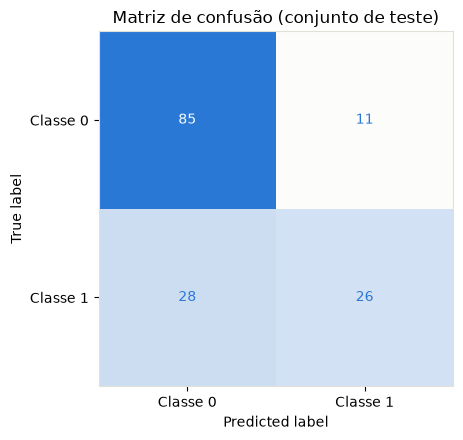

TN=85  FP=11  FN=28  TP=26


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cv, y_cv, test_size=0.3, stratify=y_cv, random_state=RANDOM_STATE
)

modelo_metrics = LogisticRegression(max_iter=1000)
modelo_metrics.fit(X_train, y_train)

y_pred = modelo_metrics.predict(X_test)
y_proba = modelo_metrics.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)

cmap_seq = mcolors.LinearSegmentedColormap.from_list("seq_azul", ["#fcfcfb", BLUE])
fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Classe 0", "Classe 1"])
disp.plot(ax=ax, cmap=cmap_seq, colorbar=False, values_format="d")
ax.set_title("Matriz de confusão (conjunto de teste)")
ax.grid(False)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

A partir de TP, TN, FP e FN, definimos:

**Acurácia** — proporção geral de acertos:
$$\text{Acurácia} = \frac{TP + TN}{TP + TN + FP + FN}$$
*Cuidado*: em problemas desbalanceados (ex.: 95% de uma classe), um modelo que sempre prevê a classe majoritária pode ter acurácia alta e ainda assim ser inútil.

**Precisão (Precision)** — das vezes que o modelo previu positivo, quantas estava certo:
$$\text{Precisão} = \frac{TP}{TP + FP}$$
Importante quando o custo de um **falso positivo** é alto (ex.: marcar um e-mail legítimo como spam).

**Recall (Sensibilidade / Revocação)** — das observações realmente positivas, quantas o modelo conseguiu identificar:
$$\text{Recall} = \frac{TP}{TP + FN}$$
Importante quando o custo de um **falso negativo** é alto (ex.: deixar de diagnosticar uma doença).

**Especificidade** — das observações realmente negativas, quantas o modelo identificou corretamente:
$$\text{Especificidade} = \frac{TN}{TN + FP}$$

**F1-score** — média harmônica entre precisão e recall, útil quando queremos um único número que equilibre os dois:
$$F_1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}}$$

Existe sempre um **trade-off** entre precisão e recall: tornar o modelo mais "cauteloso" (só prever positivo quando muito confiante) tende a aumentar a precisão e reduzir o recall, e vice-versa. Qual métrica priorizar depende do problema.


In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Acurácia : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}")

Acurácia : 0.740
Precisão : 0.703
Recall   : 0.481
F1-score : 0.571
AUC-ROC  : 0.741



O `scikit-learn` também oferece um relatório completo, com essas métricas calculadas **por classe**, através de `classification_report`:


In [15]:
print(classification_report(y_test, y_pred, target_names=["Classe 0", "Classe 1"]))

              precision    recall  f1-score   support

    Classe 0       0.75      0.89      0.81        96
    Classe 1       0.70      0.48      0.57        54

    accuracy                           0.74       150
   macro avg       0.73      0.68      0.69       150
weighted avg       0.73      0.74      0.73       150



**Curva ROC e AUC**

A regressão logística não produz apenas uma classe, ela produz uma **probabilidade**. Por padrão, usamos o limiar (threshold) de 0.5 para converter probabilidade em classe, mas esse limiar pode ser ajustado.

A **curva ROC** (Receiver Operating Characteristic) mostra, para *todos os limiares possíveis*, a relação entre:

- **Taxa de Verdadeiros Positivos** (TPR = Recall = $TP/(TP+FN)$), no eixo Y
- **Taxa de Falsos Positivos** (FPR = $FP/(FP+TN)$), no eixo X

Um modelo perfeito passaria pelo canto superior esquerdo (TPR=1, FPR=0). Um modelo aleatório fica sobre a diagonal. A **AUC (Area Under the Curve)** resume a curva em um único número entre 0 e 1: a probabilidade de que o modelo dê uma pontuação mais alta a uma observação positiva escolhida aleatoriamente do que a uma observação negativa escolhida aleatoriamente. AUC = 0.5 é equivalente a "chutar"; AUC = 1.0 é separação perfeita.

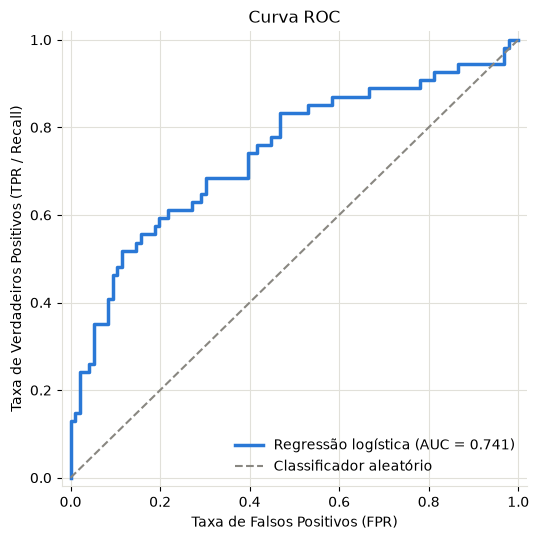

In [16]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr, tpr, color=BLUE, linewidth=2.5, label=f"Regressão logística (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1.5, label="Classificador aleatório")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR / Recall)")
ax.set_title("Curva ROC")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Quando as classes são muito **desbalanceadas**, a curva ROC pode parecer "otimista demais", porque a FPR usa TN no denominador, e TN costuma ser um número grande quando a classe negativa é predominante. Nesses casos, a **curva Precisão-Recall (PR)** costuma ser mais informativa, pois foca inteiramente na classe positiva (a de interesse).

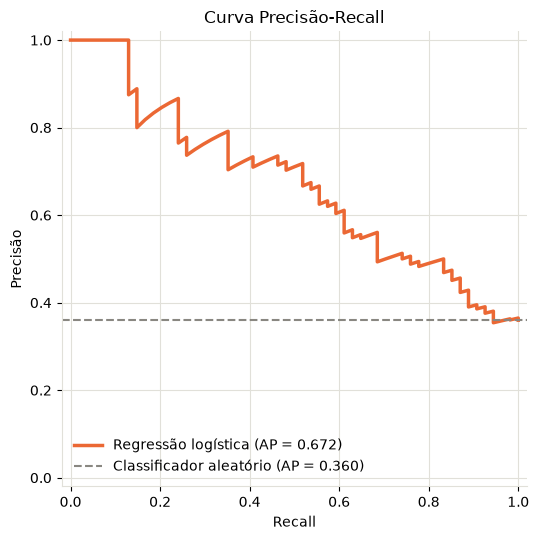

In [17]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
baseline_pr = y_test.mean()  # desempenho de um classificador aleatório na curva PR

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(recalls, precisions, color=ORANGE, linewidth=2.5, label=f"Regressão logística (AP = {ap:.3f})")
ax.axhline(baseline_pr, color=GRAY, linestyle="--", linewidth=1.5,
           label=f"Classificador aleatório (AP = {baseline_pr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisão")
ax.set_title("Curva Precisão-Recall")
ax.legend(frameon=False, loc="lower left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


Vamos ajustar o limiar de decisão.

Por padrão, o `scikit-learn` usa o limiar 0.5 para transformar probabilidade em classe. Mas nada nos obriga a usar esse valor! Dependendo do problema, pode ser preferível um limiar mais baixo (para aumentar o recall, à custa de precisão) ou mais alto (para aumentar a precisão, à custa de recall).

Por exemplo, em triagem médica, geralmente preferimos um limiar mais baixo (capturar o máximo possível de casos positivos, mesmo com mais falsos alarmes) — o custo de um falso negativo (deixar passar uma doença) é maior que o de um falso positivo (um exame extra).

Vamos ver como as métricas mudam para diferentes limiares.

In [18]:
def metricas_no_limiar(y_true, proba, limiar):
    pred = (proba >= limiar).astype(int)
    return {
        "limiar": limiar,
        "precisão": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "acurácia": accuracy_score(y_true, pred),
    }

tabela_limiares = pd.DataFrame([
    metricas_no_limiar(y_test, y_proba, t) for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
]).set_index("limiar")

tabela_limiares.round(3)


,precisão,recall,f1,acurácia
limiar,,,,
0.2,0.460,0.852,0.597,0.587
0.3,0.506,0.722,0.595,0.647
0.4,0.625,0.556,0.588,0.720
0.5,0.703,0.481,0.571,0.740
0.6,0.773,0.315,0.447,0.720
0.7,0.812,0.241,0.371,0.707
0.8,0.875,0.130,0.226,0.680



Repare como reduzir o limiar aumenta o recall (capturamos mais positivos reais) mas reduz a precisão (também capturamos mais falsos positivos). isto é o trade-off clássico entre as duas métricas. A escolha do limiar ideal depende do **custo relativo** de cada tipo de erro no problema em questão, não de uma regra matemática universal.

### 6. Dados reais

Agora que entendemos a teoria e vimos o modelo funcionando em dados sintéticos, vamos aplicar exatamente o mesmo processo a um problema real: o **Breast Cancer Wisconsin (Diagnostic) Dataset**, disponível diretamente no `scikit-learn`.

Esse conjunto de dados contém características extraídas de imagens digitalizadas de biópsias por agulha fina de massas mamárias (ex.: raio médio, textura, perímetro, área, suavidade das células, etc.), e o objetivo é prever se o tumor é **maligno** ou **benigno**. É um problema clássico e muito usado para ensinar classificação binária, com relevância prática real.

In [19]:
dados = load_breast_cancer(as_frame=True)
df = dados.frame.copy()

# No dataset original, target=0 é maligno e target=1 é benigno.
# Vamos deixar isso explícito com uma coluna de rótulo legível.
df["diagnostico"] = df["target"].map({0: "maligno", 1: "benigno"})

print("Formato do dataset:", df.shape)
df.head()


Formato do dataset: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


In [20]:
print(dados.DESCR.split("\n\n")[1])  # descrição resumida do dataset

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------


diagnostico
benigno    357
maligno    212
Name: count, dtype: int64


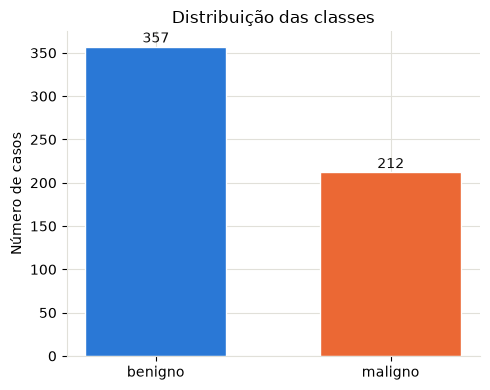


Proporção de casos malignos: 37.3%


In [21]:
contagem = df["diagnostico"].value_counts()
print(contagem)

fig, ax = plt.subplots(figsize=(5, 4))
cores = [ORANGE if c == "maligno" else BLUE for c in contagem.index]
ax.bar(contagem.index, contagem.values, color=cores, edgecolor="white", width=0.6)
ax.set_ylabel("Número de casos")
ax.set_title("Distribuição das classes")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 5, str(v), ha="center", color=INK)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nProporção de casos malignos: {(df['target']==0).mean():.1%}")



As classes não estão perfeitamente balanceadas (mais casos benignos do que malignos), o que reforça a importância de olharmos além da acurácia — precisão, recall e F1 (em particular para a classe "maligno", que é a mais crítica de não deixar passar) contam uma história mais completa.

Vamos examinar quais variáveis (features) têm maior correlação linear com o diagnóstico.


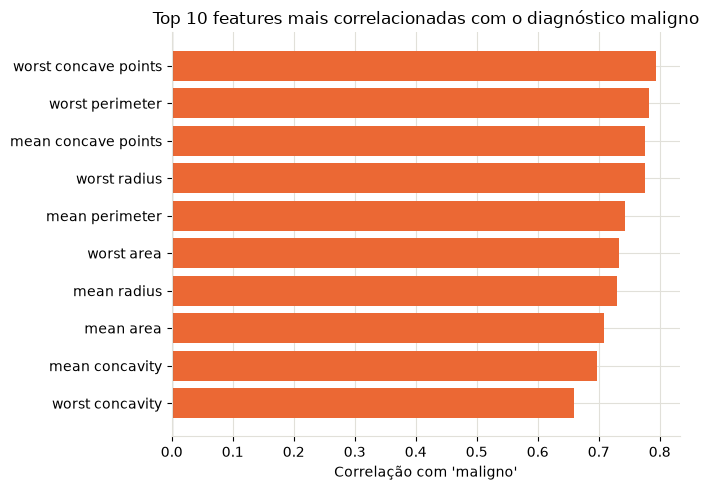

In [22]:
# target=1 é benigno; para que "correlação positiva" tenha uma leitura intuitiva,
# criamos uma variável auxiliar maligno=1/0 apenas para esta análise exploratória.
df["maligno"] = 1 - df["target"]

correlacoes = (
    df.drop(columns=["target", "diagnostico"])
    .corr(numeric_only=True)["maligno"]
    .drop("maligno")
    .sort_values(key=np.abs, ascending=False)
)

top10 = correlacoes.head(10)

fig, ax = plt.subplots(figsize=(7, 5))
cores_corr = [ORANGE if v > 0 else BLUE for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=cores_corr[::-1])
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel("Correlação com 'maligno'")
ax.set_title("Top 10 features mais correlacionadas com o diagnóstico maligno")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


Regressão logística é sensível à **escala** das variáveis: como o modelo é ajustado via otimização numérica e regularizado (penalizando o tamanho dos coeficientes), variáveis em escalas muito diferentes (ex.: "área" na casa de milhares vs. "suavidade" entre 0 e 1) podem distorcer o processo de otimização e a regularização. Por isso, é boa prática **padronizar** as variáveis (média 0, desvio-padrão 1) com `StandardScaler` antes de treinar.

**Cuidado com vazamento de dados (data leakage)**: o `StandardScaler` deve ser **ajustado (fit) apenas nos dados de treino**, e depois aplicado (transform) tanto no treino quanto no teste. Se ajustássemos o scaler no dataset inteiro antes de dividir, informação do conjunto de teste "vazaria" para o treino através das estatísticas (média/desvio) usadas na padronização. A forma mais segura e limpa de garantir isso é usando um `Pipeline`, que encapsula o pré-processamento e o modelo em um único objeto.


In [23]:
X = dados.data
y = dados.target  # 0 = maligno, 1 = benigno

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

print("Tamanho do treino:", X_train.shape[0])
print("Tamanho do teste :", X_test.shape[0])


Tamanho do treino: 426
Tamanho do teste : 143


Assim como fizemos com os dados sintéticos, vamos avaliar o pipeline com validação cruzada estratificada de 5 folds, aplicada **apenas ao conjunto de treino** (o conjunto de teste fica reservado, intocado, para a avaliação final). Como usamos um `Pipeline`, o `StandardScaler` é reajustado corretamente em cada fold, sem vazamento de dados.


In [24]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_real_cv = cross_validate(
    pipeline, X_train, y_train,
    cv=cv5,
    scoring=metricas,   # ["accuracy", "precision", "recall", "f1", "roc_auc"]
    return_train_score=False,
)

resumo_real_cv = pd.DataFrame({
    metrica: [
        resultados_real_cv[f"test_{metrica}"].mean(),
        resultados_real_cv[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["média", "desvio-padrão"]).T

resumo_real_cv.round(3)


,média,desvio-padrão
accuracy,0.979,0.009
precision,0.974,0.015
recall,0.993,0.009
f1,0.983,0.007
roc_auc,0.996,0.004



Note o desvio-padrão baixo entre os folds: um bom sinal de que o desempenho do modelo é consistente, e não um resultado de sorte em uma única divisão dos dados.

Finalmente,  treinamos o pipeline em **todo o conjunto de treino** e avaliamos, pela primeira e única vez, no conjunto de teste, que até aqui não foi usado para nenhuma decisão sobre o modelo.


In [25]:
pipeline.fit(X_train, y_train)

y_pred_real = pipeline.predict(X_test)
y_proba_real = pipeline.predict_proba(X_test)[:, 1]  # probabilidade de ser "benigno" (classe 1)

print(f"Acurácia : {accuracy_score(y_test, y_pred_real):.3f}")
print(f"Precisão : {precision_score(y_test, y_pred_real):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_real):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_real):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba_real):.3f}")
print()
print(classification_report(y_test, y_pred_real, target_names=["maligno", "benigno"]))

Acurácia : 0.986
Precisão : 0.989
Recall   : 0.989
F1-score : 0.989
AUC-ROC  : 0.998

              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        53
     benigno       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



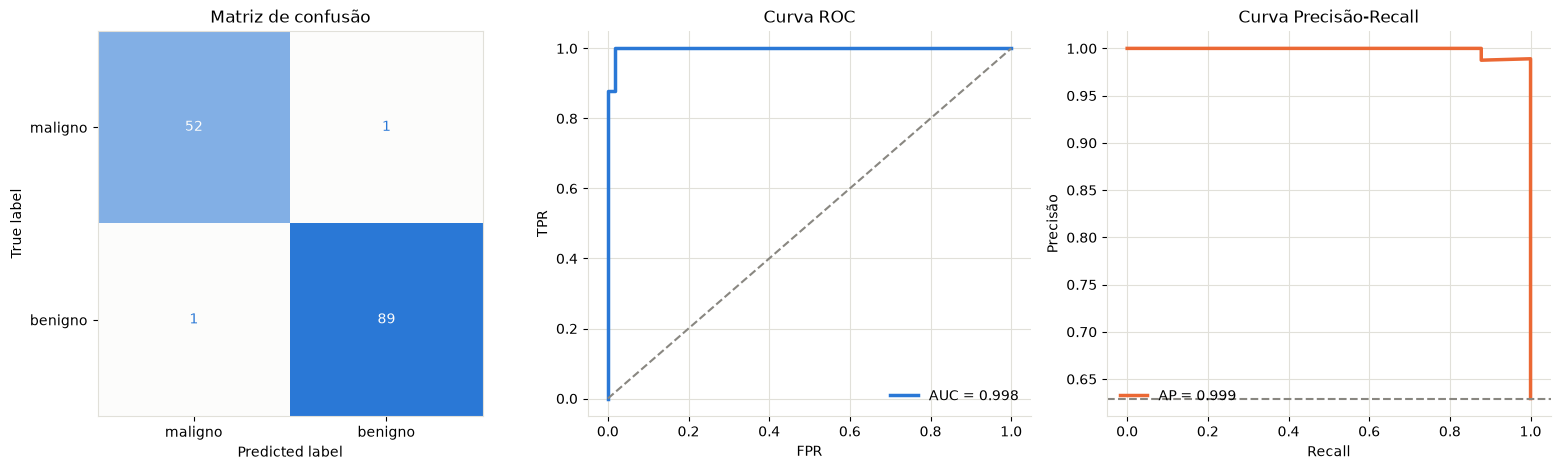

In [26]:
cm_real = confusion_matrix(y_test, y_pred_real)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- Matriz de confusão ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm_real, display_labels=["maligno", "benigno"])
disp.plot(ax=axes[0], cmap=cmap_seq, colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusão")
axes[0].grid(False)

# --- Curva ROC ---
fpr_r, tpr_r, _ = roc_curve(y_test, y_proba_real)
auc_r = roc_auc_score(y_test, y_proba_real)
axes[1].plot(fpr_r, tpr_r, color=BLUE, linewidth=2.5, label=f"AUC = {auc_r:.3f}")
axes[1].plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC")
axes[1].legend(frameon=False, loc="lower right")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

# --- Curva Precisão-Recall ---
prec_r, rec_r, _ = precision_recall_curve(y_test, y_proba_real)
ap_r = average_precision_score(y_test, y_proba_real)
axes[2].plot(rec_r, prec_r, color=ORANGE, linewidth=2.5, label=f"AP = {ap_r:.3f}")
axes[2].axhline(y_test.mean(), color=GRAY, linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisão")
axes[2].set_title("Curva Precisão-Recall")
axes[2].legend(frameon=False, loc="lower left")
for spine in ["top", "right"]:
    axes[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


Como padronizamos as variáveis antes de treinar, os coeficientes já são diretamente comparáveis entre si: cada um representa o efeito de **um desvio-padrão** de aumento naquela variável (e não de "uma unidade", que teria escalas muito diferentes de feature para feature).

Vamos extrair os coeficientes do modelo dentro do pipeline e visualizar quais variáveis mais aumentam ou diminuem a chance de o tumor ser classificado como **benigno** (lembrando: classe 1 = benigno neste dataset).


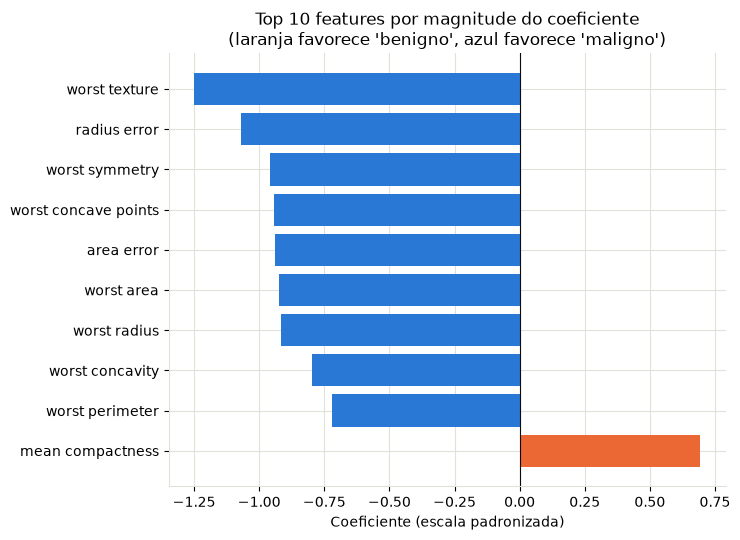

,feature,coeficiente,odds_ratio
21,worst texture,-1.250149,0.286462
10,radius error,-1.070102,0.342973
28,worst symmetry,-0.957045,0.384026
27,worst concave points,-0.941888,0.389891
13,area error,-0.941059,0.390214
23,worst area,-0.925812,0.396210
20,worst radius,-0.917480,0.399525
26,worst concavity,-0.796758,0.450788
22,worst perimeter,-0.721168,0.486184
5,mean compactness,0.694230,2.002167


In [27]:
logreg_final = pipeline.named_steps["logreg"]

coefs_reais = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": logreg_final.coef_[0],
})
coefs_reais["odds_ratio"] = np.exp(coefs_reais["coeficiente"])
coefs_reais = coefs_reais.reindex(coefs_reais["coeficiente"].abs().sort_values(ascending=False).index)

top_coefs = coefs_reais.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
cores_coef = [ORANGE if v > 0 else BLUE for v in top_coefs["coeficiente"]]
ax.barh(top_coefs["feature"], top_coefs["coeficiente"], color=cores_coef)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel("Coeficiente (escala padronizada)")
ax.set_title("Top 10 features por magnitude do coeficiente\n(laranja favorece 'benigno', azul favorece 'maligno')")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

coefs_reais.head(10)



Isso é uma das grandes vantagens da regressão logística em relação a modelos mais "caixa-preta": ela é diretamente **interpretável**. Um(a) profissional de saúde pode olhar para essa lista e entender quais características das células estão mais associadas a tumores malignos, o que ajuda a validar clinicamente se o modelo está aprendendo algo sensato (por exemplo, é esperado que maior "worst concave points" e "worst perimeter" estejam associados a malignidade).

> **Nota importante**: correlação (e mesmo o coeficiente de um modelo) não implica causalidade.


### 7. Ajuste de hiperparâmetros

Até agora usamos os hiperparâmetros padrão do `LogisticRegression`. Podemos tentar melhorar o modelo ajustando:

- **`C`**: o inverso da força de regularização (valores menores = mais regularização).
- **`penalty`**: tipo de regularização (`l2` é o padrão; `l1` pode zerar coeficientes, funcionando como seleção de variáveis).

Vamos usar `GridSearchCV`, que testa exaustivamente combinações de hiperparâmetros usando validação cruzada, escolhendo a combinação com melhor desempenho médio segundo uma métrica escolhida. Aqui, vamos otimizar para `f1`, já que nos importamos tanto com precisão quanto com recall neste problema.


In [28]:

pipeline_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)),
])

param_grid = {
    "logreg__C": [0.01, 0.1, 0.5, 1, 5, 10, 50],
    "logreg__penalty": ["l1", "l2"],
}

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=cv5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print(f"Melhor F1 médio (validação cruzada): {grid_search.best_score_:.3f}")


Melhores hiperparâmetros: {'logreg__C': 0.5, 'logreg__penalty': 'l2'}
Melhor F1 médio (validação cruzada): 0.985


In [29]:
melhor_modelo = grid_search.best_estimator_
y_pred_tuned = melhor_modelo.predict(X_test)
y_proba_tuned = melhor_modelo.predict_proba(X_test)[:, 1]

comparacao = pd.DataFrame({
    "modelo_base (C=1.0, l2)": {
        "acurácia": accuracy_score(y_test, y_pred_real),
        "precisão": precision_score(y_test, y_pred_real),
        "recall": recall_score(y_test, y_pred_real),
        "f1": f1_score(y_test, y_pred_real),
        "auc": roc_auc_score(y_test, y_proba_real),
    },
    "modelo ajustado (GridSearchCV)": {
        "acurácia": accuracy_score(y_test, y_pred_tuned),
        "precisão": precision_score(y_test, y_pred_tuned),
        "recall": recall_score(y_test, y_pred_tuned),
        "f1": f1_score(y_test, y_pred_tuned),
        "auc": roc_auc_score(y_test, y_proba_tuned),
    },
}).T

comparacao.round(3)


,acurácia,precisão,recall,f1,auc
"modelo_base (C=1.0, l2)",0.986,0.989,0.989,0.989,0.998
modelo ajustado (GridSearchCV),0.986,0.989,0.989,0.989,0.998



Em muitos casos, o ajuste de hiperparâmetros traz ganhos modestos (o modelo padrão da regressão logística já costuma ser um bom ponto de partida), mas o processo é importante para (a) confirmar que não estamos deixando desempenho na mesa e (b) obter, via regularização L1, uma leitura de quais variáveis o modelo considera dispensáveis (coeficiente zerado).


In [30]:

if grid_search.best_params_["logreg__penalty"] == "l1":
    coefs_l1 = pd.Series(
        melhor_modelo.named_steps["logreg"].coef_[0], index=X.columns
    )
    zeradas = coefs_l1[coefs_l1 == 0].index.tolist()
    print(f"Número de coeficientes zerados pela regularização L1: {len(zeradas)} de {len(coefs_l1)}")
    if zeradas:
        print("Features descartadas pelo modelo:", zeradas)
else:
    print("O melhor modelo usou regularização L2 (não zera coeficientes, apenas os encolhe).")


O melhor modelo usou regularização L2 (não zera coeficientes, apenas os encolhe).


### 8. Quando usar (e quando não usar) regressão logística

**Pontos fortes:**
- Rápida de treinar, mesmo em datasets grandes.
- Altamente interpretável (coeficientes = odds ratios).
- Produz probabilidades calibradas de forma razoável, não apenas classes.
- Ótimo baseline antes de partir para modelos mais complexos.

**Limitações:**
- Assume uma fronteira de decisão **linear** no espaço dos logits — não captura relações complexas e não-lineares sem engenharia de atributos (ex.: termos polinomiais, interações).
- Sensível a variáveis em escalas muito diferentes (por isso a padronização é importante).
- Sensível a multicolinearidade entre variáveis explicativas.
- Como qualquer modelo, sensível a classes muito desbalanceadas — nesses casos vale considerar ponderação de classes (`class_weight="balanced"`), reamostragem, ou métricas como AUC-PR em vez de acurácia.

### Exercícios de fixação

1 — Considere um problema de classificação binária com classes desbalanceadas. Treine dois modelos de regressão logística:
   - um modelo sem ajuste de pesos;
   - outro modelo com class_weight="balanced".
Avalie os dois modelos usando o mesmo procedimento de validação cruzada estratificada.

In [16]:
# ============================================================
# Exercício 1 — regressão logística com classes desbalanceadas
# ============================================================
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import recall_score, make_scorer

import pandas as pd

RANDOM_STATE = 42

# não são 50/50 (mais casos benignos do que malignos), o que já é suficiente
# para ilustrar o efeito do parâmetro class_weight="balanced".
dados_ex1 = load_breast_cancer(as_frame=True)

X_ex1 = dados_ex1.data
y_ex1 = dados_ex1.target  # 0 = maligno (classe minoritária), 1 = benigno (classe majoritária)

print("Proporção de cada classe:")
print(y_ex1.value_counts(normalize=True).rename({0: "maligno", 1: "benigno"}).round(3))

# --- Modelo 1: sem ajuste de pesos (comportamento padrão do LogisticRegression) ---
# Padronizamos as variáveis dentro de um Pipeline, como fizemos na Seção 6,
# pois a regressão logística é sensível à escala dos atributos.
pipeline_sem_peso = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

# --- Modelo 2: com class_weight="balanced" ---
# Esse parâmetro pondera a função de custo de forma inversamente proporcional
# à frequência de cada classe, penalizando mais os erros cometidos na classe
# minoritária ("maligno"), sem precisar reamostrar os dados.
pipeline_balanceado = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
])

# Mesmo esquema de validação cruzada estratificada usado no restante do notebook.
# Reutilizar o MESMO objeto StratifiedKFold para os dois modelos garante que
# ambos sejam avaliados exatamente nos mesmos folds, tornando a comparação justa.
cv_ex1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Além das métricas "padrão" (que por convenção do sklearn tratam a classe 1,
# benigno, como positiva), incluímos o recall da classe 0 (maligno) via
# make_scorer: é a métrica mais sensível ao desbalanceamento, já que deixar
# passar um caso maligno (falso negativo) é o erro mais grave neste problema.
scoring_ex1 = {
    "accuracy": "accuracy",
    "precisão (benigno)": "precision",
    "recall (benigno)": "recall",
    "f1 (benigno)": "f1",
    "roc_auc": "roc_auc",
    "recall (maligno)": make_scorer(recall_score, pos_label=0),
}

resultados_sem_peso = cross_validate(pipeline_sem_peso, X_ex1, y_ex1, cv=cv_ex1, scoring=scoring_ex1)
resultados_balanceado = cross_validate(pipeline_balanceado, X_ex1, y_ex1, cv=cv_ex1, scoring=scoring_ex1)

comparacao_ex1 = pd.DataFrame({
    "sem ajuste de pesos": {m: resultados_sem_peso[f"test_{m}"].mean() for m in scoring_ex1},
    "class_weight='balanced'": {m: resultados_balanceado[f"test_{m}"].mean() for m in scoring_ex1},
}).T

comparacao_ex1.round(3)

Proporção de cada classe:
target
benigno    0.627
maligno    0.373
Name: proportion, dtype: float64


,accuracy,precisão (benigno),recall (benigno),f1 (benigno),roc_auc,recall (maligno)
sem ajuste de pesos,0.974,0.968,0.992,0.979,0.995,0.944
class_weight='balanced',0.972,0.975,0.980,0.978,0.995,0.958


In [11]:
# O ganho mais informativo do class_weight="balanced" aparece no recall da
# classe minoritária (maligno): o modelo passa a "errar para o lado seguro",
# reduzindo falsos negativos, geralmente ao custo de uma pequena queda em
# precisão/acurácia geral.
delta_recall_maligno = (
    comparacao_ex1.loc["class_weight='balanced'", "recall (maligno)"]
    - comparacao_ex1.loc["sem ajuste de pesos", "recall (maligno)"]
)
print(f"Ganho de recall na classe 'maligno' ao usar class_weight='balanced': {delta_recall_maligno:+.3f}")

Ganho de recall na classe 'maligno' ao usar class_weight='balanced': +0.014


2 - Escolha um conjunto de dados com três ou mais classes e compare os seguintes classificadores:
- regressão logística;
- árvore de decisão;
- knn

Qual modelo apresentou o melhor desempenho médio na validação cruzada? E no conjunto de teste?

In [4]:
# ============================================================
# Exercício 2 — comparando classificadores em um problema multiclasse
# ============================================================
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

# Dataset: Wine Quality (tinto). O alvo `quality` é a nota sensorial dada ao
# vinho, um inteiro entre 3 e 8 — um problema de classificação com 6 classes,
# nem todas igualmente representadas (poucos vinhos com nota 3 ou 8; a
# maioria tem nota 5 ou 6).
caminho_wine = "C:\\Users\\saulosgil\\OneDrive\\Documentos\\CursoMLeCD-USP\\data\\winequality-red.csv"
df_wine = pd.read_csv(caminho_wine)

print("Formato do dataset:", df_wine.shape)
print("\nDistribuição das classes (quality):")
print(df_wine["quality"].value_counts().sort_index())

X_wine = df_wine.drop(columns="quality")
y_wine = df_wine["quality"]

# Separamos um conjunto de teste "intocado", assim como fizemos com o Breast
# Cancer. stratify=y_wine garante que cada classe apareça em treino e teste
# na mesma proporção do dataset original — importante com classes raras
# (ex.: quality=3, com poucas observações).
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.25, stratify=y_wine, random_state=RANDOM_STATE
)

# Três classificadores a comparar. Regressão logística e KNN são sensíveis à
# escala das variáveis, então usamos um Pipeline com StandardScaler para os
# dois; a árvore de decisão não precisa de padronização (é invariante a
# transformações monotônicas de cada atributo, já que decide por limiares).
modelos_ex2 = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5)),
    ]),
}

# Com mais de duas classes, usamos métricas multiclasse:
# - accuracy: proporção geral de acertos.
# - f1_macro: média do F1 calculado classe a classe (sem peso extra para as
#   classes mais frequentes) — bom indicador de desempenho nas classes raras.
cv_ex2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv_ex2 = {}
for nome, modelo in modelos_ex2.items():
    scores = cross_validate(
        modelo, X_train_wine, y_train_wine,
        cv=cv_ex2, scoring=["accuracy", "f1_macro"],
    )
    resultados_cv_ex2[nome] = {
        "accuracy (cv)": scores["test_accuracy"].mean(),
        "f1_macro (cv)": scores["test_f1_macro"].mean(),
    }

resumo_cv_ex2 = pd.DataFrame(resultados_cv_ex2).T
print("\nDesempenho médio na validação cruzada (5 folds, apenas treino):")
resumo_cv_ex2.round(3)

Formato do dataset: (1599, 12)

Distribuição das classes (quality):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Desempenho médio na validação cruzada (5 folds, apenas treino):


,accuracy (cv),f1_macro (cv)
Regressão Logística,0.596,0.290
Árvore de Decisão,0.587,0.317
KNN,0.576,0.293


In [6]:
from sklearn.metrics import accuracy_score, f1_score

# Agora treinamos cada modelo no conjunto de treino completo e avaliamos,
# uma única vez, no conjunto de teste (que ficou de fora da validação cruzada).
resultados_teste_ex2 = {}
for nome, modelo in modelos_ex2.items():
    modelo.fit(X_train_wine, y_train_wine)
    y_pred_wine = modelo.predict(X_test_wine)
    resultados_teste_ex2[nome] = {
        "accuracy (teste)": accuracy_score(y_test_wine, y_pred_wine),
        "f1_macro (teste)": f1_score(y_test_wine, y_pred_wine, average="macro"),
    }

resumo_teste_ex2 = pd.DataFrame(resultados_teste_ex2).T

# Junta os resultados de validação cruzada (treino) e do conjunto de teste
# em uma única tabela para facilitar a comparação.
comparacao_ex2 = resumo_cv_ex2.join(resumo_teste_ex2)
comparacao_ex2.round(3)

,accuracy (cv),f1_macro (cv),accuracy (teste),f1_macro (teste)
Regressão Logística,0.596,0.290,0.595,0.272
Árvore de Decisão,0.587,0.317,0.582,0.361
KNN,0.576,0.293,0.602,0.288


In [7]:
# Respondendo às perguntas do enunciado: qual modelo teve o melhor
# desempenho médio (f1_macro) na validação cruzada, e qual teve o melhor
# desempenho no conjunto de teste?
melhor_cv = comparacao_ex2["f1_macro (cv)"].idxmax()
melhor_teste = comparacao_ex2["f1_macro (teste)"].idxmax()
print(f"Melhor modelo na validação cruzada (f1_macro): {melhor_cv}")
print(f"Melhor modelo no conjunto de teste (f1_macro): {melhor_teste}")

Melhor modelo na validação cruzada (f1_macro): Árvore de Decisão
Melhor modelo no conjunto de teste (f1_macro): Árvore de Decisão
